In [2]:
import pandas as pd
from glob import glob
import re

def concat_all_acc_tsv(acc_tsv_list, task):
    all_sub_mean_acc_df = pd.DataFrame()
    
    for acc_path in acc_tsv_list:  # 各被験者のaccuracy.tsvを読み込み
        df_overt = pd.read_csv(acc_path, sep='\t')
        js_name = re.search(r'js\d{2}', acc_path).group()
        # 各chごとに平均を計算
        mean_acc = df_overt.mean(axis=0)
        # DataFrame化して列名をsubject名に
        mean_acc_df = pd.DataFrame(mean_acc)
        mean_acc_df.columns = [js_name]
        # all_sub_mean_acc_dfに追加（chがindex, subjectが列になるように）
        all_sub_mean_acc_df = pd.concat([all_sub_mean_acc_df, mean_acc_df], axis=1)

    new_index = [f"{task}_{index.replace('ch01', 'eog_h').replace('ch02', 'eog_v')}" for index in all_sub_mean_acc_df.index]
    all_sub_mean_acc_df.index = new_index
    
    return all_sub_mean_acc_df

/Users/murakamishoya/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
overt_tsv_dir = 'results_sp_eog_2600'
acc_paths = sorted(glob(f'{overt_tsv_dir}/spec0_350_eog/*_accuracy.tsv'))
overt_eog_acc = concat_all_acc_tsv(acc_paths, task='overt')
overt_eog_acc

In [3]:
covert_tsv_dir = 'results_sp_eog_2600_covert'
acc_paths = sorted(glob(f'{covert_tsv_dir}/spec0_350_eog/*_accuracy.tsv'))
covert_eog_acc = concat_all_acc_tsv(acc_paths, task='covert')
covert_eog_acc

,js01,js02,js04,js05,js07,js08,js11,js13,js14,js15,js16
covert_eog_h,0.27375,0.10125,0.13375,0.1475,0.17625,0.19375,0.22875,0.16125,0.168583,0.107143,0.194667
covert_eog_v,0.19750,0.08000,0.10125,0.1325,0.07000,0.11250,0.08000,0.09375,0.058000,0.045714,0.060000


In [5]:
# overt_tsv_dir = 'results_sp_eog_2600'
# acc_paths = sorted(glob(f'{overt_tsv_dir}/spec280_350_eog/*_accuracy.tsv'))
# overt_eog_acc_280350 = concat_all_acc_tsv(acc_paths, task='overt')
# overt_eog_acc_280350.to_csv('overt_eog_acc_280350.csv')
overt_tsv_dir = 'results_sp_eog_2600'
acc_paths = sorted(glob(f'{overt_tsv_dir}/spec70_140_eog/*_accuracy.tsv'))
overt_eog_acc_70140 = concat_all_acc_tsv(acc_paths, task='overt')
overt_eog_acc_70140.to_csv('overt_eog_acc_70140.csv')

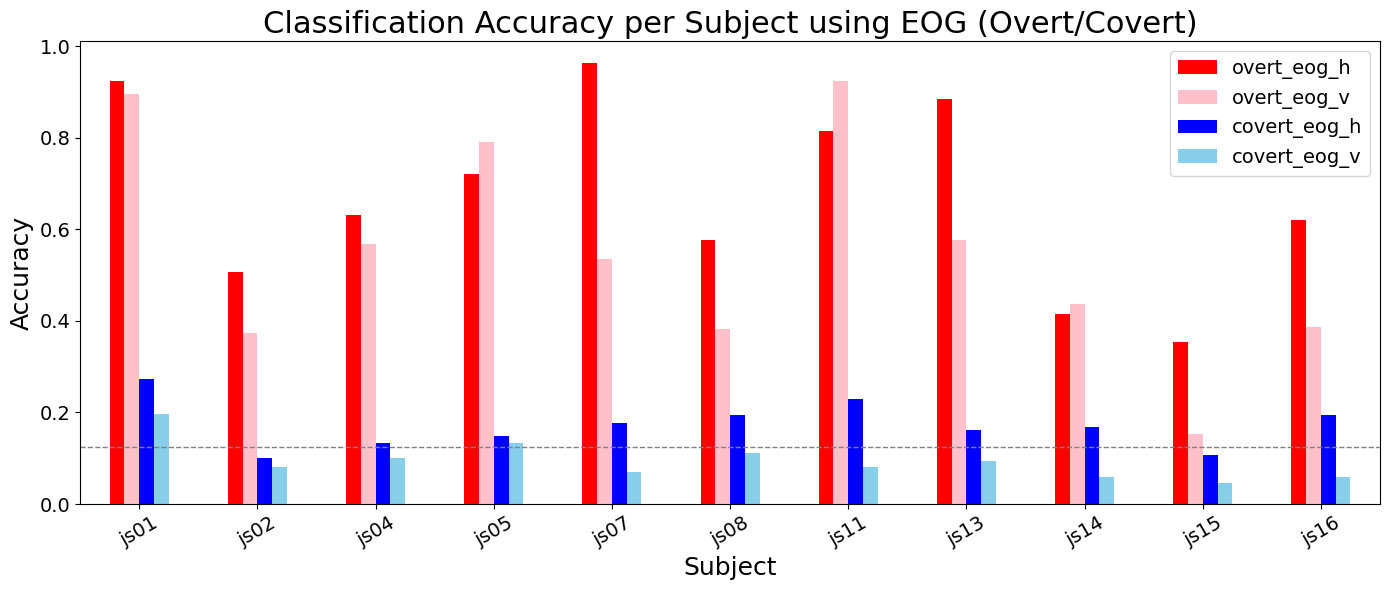

In [19]:
o_c_concated_df = pd.concat([overt_eog_acc, covert_eog_acc], axis=0)

import matplotlib.pyplot as plt

# 4列（overt_eog_h, overt_eog_v, covert_eog_h, covert_eog_v）で色を指定して棒グラフを描画
# 色を辞書で管理
color_dict = {
    'overt_eog_h': 'red',   # 青
    'overt_eog_v': 'pink',   # オレンジ
    'covert_eog_h': 'blue',  # 緑
    'covert_eog_v': 'skyblue'   # 赤
}
# 辞書のキーでカラム順を指定し、データを転置して抽出
cols = list(color_dict.keys())
plot_df = o_c_concated_df.T[cols]
colors = [color_dict[col] for col in cols]

ax = plot_df.plot(kind='bar', figsize=(14, 6), color=colors)
plt.ylabel('Accuracy', fontsize=18)
plt.xlabel('Subject', fontsize=18)
plt.title('Classification Accuracy per Subject using EOG (Overt/Covert)', fontsize=22)
plt.legend(loc='upper right', fontsize=14, title_fontsize=16)
plt.axhline(1/8, color='gray', linestyle='--', linewidth=1, label='chance level (0.125)')
plt.xticks(fontsize=14, rotation=30)  # 横軸ラベルを斜め（30度）にする
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()


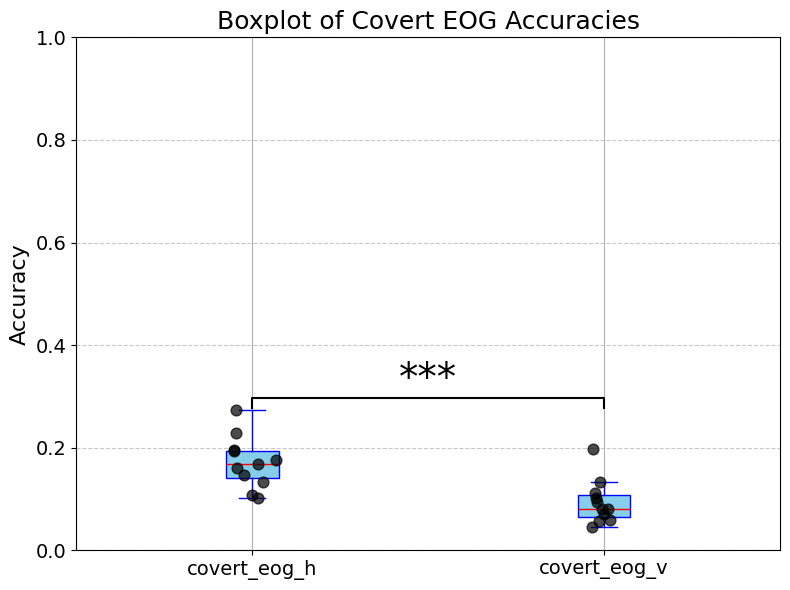

In [17]:
# covert_eog_accの箱ひげ図＋各点をプロット＋対応ありt検定で有意差があれば*を表示
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_rel

plt.figure(figsize=(8, 6))

# データを転置して条件ごと（covert_eog_h, covert_eog_v）で扱う
data = covert_eog_acc.T[['covert_eog_h', 'covert_eog_v']]

# 箱ひげ図を描画
box = data.boxplot(patch_artist=True,
                   boxprops=dict(facecolor='skyblue', color='blue'),
                   medianprops=dict(color='red'),
                   whiskerprops=dict(color='blue'),
                   capprops=dict(color='blue'),
                   showfliers=False)  # ハズレ値（外れ値）は表示しない

# 各点を重ねてプロット
for i, col in enumerate(data.columns):
    y = data[col].values
    x = np.random.normal(i+1, 0.04, size=len(y))  # 箱ひげ図のx位置に少しノイズを加えて重ならないように
    plt.scatter(x, y, color='black', alpha=0.7, s=60, zorder=3, label='_nolegend_')

# 対応ありt検定
t_stat, p_val = ttest_rel(data['covert_eog_h'], data['covert_eog_v'])

# 有意差があれば*または**を描画
if p_val < 0.05:
    # 2つの箱ひげ図の最大値を取得
    y_max = max(data['covert_eog_h'].max(), data['covert_eog_v'].max())
    y_min = min(data['covert_eog_h'].min(), data['covert_eog_v'].min())
    h = (y_max - y_min) * 0.1  # アノテーションの高さ
    y_annot = y_max + h
    plt.plot([1, 1, 2, 2], [y_max + h*0.2, y_annot, y_annot, y_max + h*0.2], color='k', linewidth=1.5)
    if p_val < 0.001:
        annot = '***'
    elif p_val < 0.01:
        annot = '**'
    else:
        annot = '*'
    plt.text(1.5, y_annot + h*0.05, annot, ha='center', va='bottom', color='k', fontsize=28)

plt.ylabel('Accuracy', fontsize=16)
plt.title('Boxplot of Covert EOG Accuracies', fontsize=18)
plt.xticks([1, 2], ['covert_eog_h', 'covert_eog_v'], fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


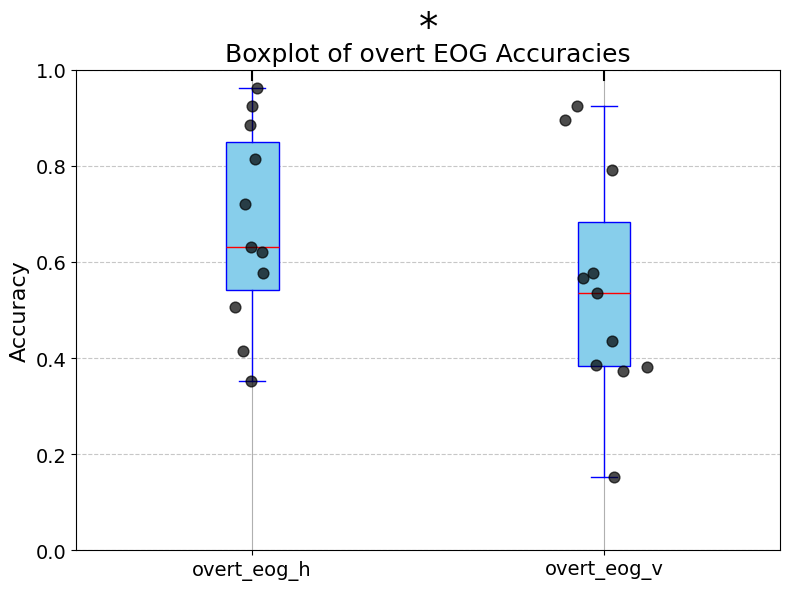

In [14]:
# covert_eog_accの箱ひげ図＋各点をプロット＋対応ありt検定で有意差があれば*を表示
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_rel

plt.figure(figsize=(8, 6))

# データを転置して条件ごと（covert_eog_h, covert_eog_v）で扱う
data = overt_eog_acc.T[['overt_eog_h', 'overt_eog_v']]

# 箱ひげ図を描画
box = data.boxplot(patch_artist=True,
                   boxprops=dict(facecolor='skyblue', color='blue'),
                   medianprops=dict(color='red'),
                   whiskerprops=dict(color='blue'),
                   capprops=dict(color='blue'),
                   showfliers=False)  # ハズレ値（外れ値）は表示しない

# 各点を重ねてプロット
for i, col in enumerate(data.columns):
    y = data[col].values
    x = np.random.normal(i+1, 0.04, size=len(y))  # 箱ひげ図のx位置に少しノイズを加えて重ならないように
    plt.scatter(x, y, color='black', alpha=0.7, s=60, zorder=3, label='_nolegend_')

# 対応ありt検定
t_stat, p_val = ttest_rel(data['overt_eog_h'], data['overt_eog_v'])

# 有意差があれば*または**を描画
if p_val < 0.05:
    # 2つの箱ひげ図の最大値を取得
    y_max = max(data['overt_eog_h'].max(), data['overt_eog_v'].max())
    y_min = min(data['overt_eog_h'].min(), data['overt_eog_v'].min())
    h = (y_max - y_min) * 0.1  # アノテーションの高さ
    y_annot = y_max + h
    plt.plot([1, 1, 2, 2], [y_max + h*0.2, y_annot, y_annot, y_max + h*0.2], color='k', linewidth=1.5)
    if p_val < 0.01:
        annot = '**'
    else:
        annot = '*'
    plt.text(1.5, y_annot + h*0.05, annot, ha='center', va='bottom', color='k', fontsize=28)

plt.ylabel('Accuracy', fontsize=16)
plt.title('Boxplot of overt EOG Accuracies', fontsize=18)
plt.xticks([1, 2], ['overt_eog_h', 'overt_eog_v'], fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/Users/murakamishoya/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/murakamishoya/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
/Users/murakamishoya/anaconda3/envs/py310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/murakamishoya/anaconda3/envs/py310/lib/python3.10/sit

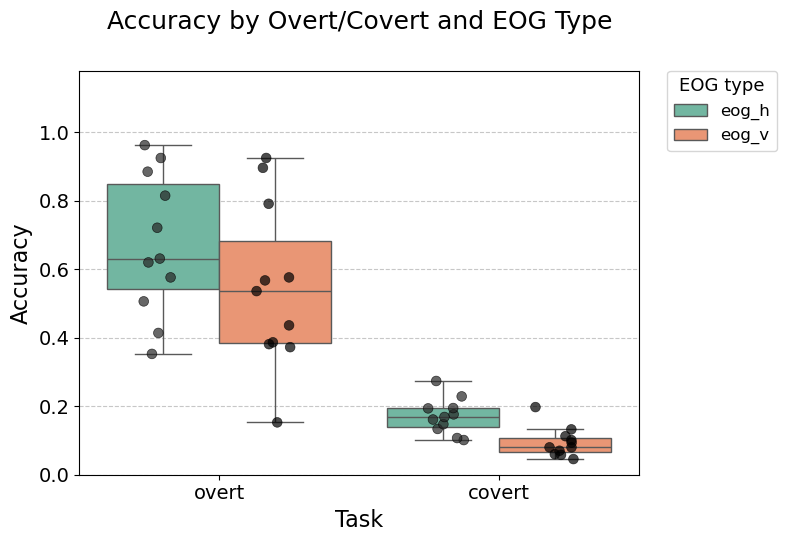

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# overt_eog_acc, covert_eog_accが既にDataFrameとして存在している前提
# データをlong形式に変換
def melt_eog(df, condition):
    df_long = df.reset_index().melt(id_vars='index', var_name='subject', value_name='accuracy')
    df_long = df_long.rename(columns={'index': 'type'})
    df_long['condition'] = condition
    return df_long

overt_long = melt_eog(overt_eog_acc, 'overt')
overt_long['eog_type'] = overt_long['type'].apply(lambda x: 'eog_h' if 'eog_h' in x else 'eog_v')
covert_long = melt_eog(covert_eog_acc, 'covert')
covert_long['eog_type'] = covert_long['type'].apply(lambda x: 'eog_h' if 'eog_h' in x else 'eog_v')

plot_df = pd.concat([overt_long, covert_long], ignore_index=True)

plt.figure(figsize=(8, 6))
sns.boxplot(data=plot_df, x='condition', y='accuracy', hue='eog_type', palette='Set2', showfliers=False)
sns.stripplot(data=plot_df, x='condition', y='accuracy', hue='eog_type', 
              dodge=True, color='black', alpha=0.7, size=7, jitter=0.15, linewidth=0.5, edgecolor='gray')

# 凡例を図の外に出す
handles, labels = plt.gca().get_legend_handles_labels()
n_types = plot_df['eog_type'].nunique()
plt.legend(handles[:n_types], labels[:n_types], title='EOG type', fontsize=12, title_fontsize=13,
           bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.ylabel('Accuracy', fontsize=16)
plt.xlabel('Task', fontsize=16)
# タイトルの上下に余白を追加
plt.title('Accuracy by Overt/Covert and EOG Type', fontsize=18, pad=30)
plt.ylim(0, 1.18)  # アスタリスク用に上下に余白を追加
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # 上下に余白を追加
plt.show()
plt.savefig('eog_acc_boxplot.svg')

In [41]:
plot_df['type'].unique()
# overt_eog_acc

array(['overt_eog_h', 'overt_eog_v', 'covert_eog_h', 'covert_eog_v'],
      dtype=object)

In [18]:
from scipy.stats import ttest_rel

# 対応ありt検定
# overt vs covert (HEOG)
o_h_t_stat, o_h_p_val = ttest_rel(data['overt_eog_h'], data['covert_eog_h'])
print(o_h_t_stat, o_h_p_val)

# overt vs covert (VEOG)
o_v_t_stat, o_v_p_val = ttest_rel(data['overt_eog_v'], data['covert_eog_v'])
print(o_v_t_stat, o_v_p_val)


# overt の v vs h
o_t_stat, o_p_val = ttest_rel(data['overt_eog_v'], data['overt_eog_h'])
print(o_t_stat, o_p_val)
# covert の v vs h
c_t_stat, c_p_val = ttest_rel(data['covert_eog_v'], data['covert_eog_h'])
print(c_t_stat, c_p_val)


9.228173624525958 3.302098132519713e-06
7.027726939900955 3.5935559190154245e-05
-2.523398655924651 0.030210834867994366
-5.806021702384227 0.000171547080492525
